# Part 1 

## Task 1, function approx 

1(*) The difference between using a linear function for freature eng. and for function approx is that feature engineering is a transformation of the input data into a more meaningul value, in the linear case taking x -> f(x) = ax and returning ax into our target function, while with function approximation you try to best represent the "true" function as a sum of linaer features. 

2()((on paper))whole point of semi-gradient is that TD(n) target depends on the params w through future value estimates, and only takes the gradient wrt. current state value estimate. 

3(*) The policy improvement theorem proves that choosing the max over future actions will and then updating the value function will lead to an improved policy for each step. This falls appart with function approximation because we no longer know the state-values and action values exactly. This means that selecting the max(q_ {pi}) is no longer guaranteed to be the mazimizing action, and that the step no longer is true.  

4(*) challenges to expect when approximating an action-value function, TD(\landa) algo and off policy behaviour B from Mars_rover1 instead of Mars_rover2: would assume you'd need some way to get the importance ratio integrated into the neural network approx? nvm. Problem here is refered to as the "deadly triad", because the combination of bootstrapping updates, function approx and off-policy learning implies that the algorithm can easily diverge. Hence, the main problem with integrating NN-approx here is the risk of algorithm divergence.

## task2, planning

1() state_value(uni), state_vaalue(home) with MC: 6/8, 0. MC estimate is simlpy avg return for all trajectories. 

2() state_value(uni), state_value(home) with TD: 6/8, \gamma*3/4

3(*) The reason we get different estimates for mc and temporal difference is that Monte Carlo simply averages the retun of the state in all trajectories, whils temporal difference uses bootstrappiing and updates wrt. current estimate of furture state values. The implication here is some coeficcient Gamma * our estimated return for v(uni), as that us the next state in the trajectory when investigating v(home)

4.. on paper untill next "oblig" task

11() sv(uni), sv(home) with dp also yields 6/8 and \gamma*6/8, (discounted val of future states, and no future state for tuple(uni, take exam))...

12(*) dp different to MC because it takes estimate for future states into accont, equal to TD in this case because target only depends on reward from next state, whilst if there were more future states than 1, they would be different. (This is simply a special case where TD(0) and the DP-estimates are equal).

15(*) The new values generated by including the simmulated data didnt change the estimates in any way. The simulated data comes from an inferred model with the same probability distribution as our original estimates, which explains why new trajectories drawn from the simulated model M doesnt change our estimated values. 

# Ex3. Monte Carlo Tree Search 

1(*) first consideration when thinking about montre carlo tree search for self-driving cars: state, action space is continous for the self-driving problem, whereas mcts is typically used where one has discrete states, actions. Further on, it is hard to come up with a good simulator for self-driving, and the environment is also dynamic(changing continously, think pedestrians, lights, other cars etc), which makes it a lot harder. 

# PART 2, 

## Ex4, feature eng.

In [29]:
#task 1, uniform discretization step? 
import gymnasium as gym    
env = gym.make("MountainCar-v0", render_mode="human")
import inspect

print("Env class:", env.unwrapped.__class__)
print("Source file:", inspect.getfile(env.unwrapped.__class__))
print(inspect.getsource(env.unwrapped.__class__))

Env class: <class 'gymnasium.envs.classic_control.mountain_car.MountainCarEnv'>
Source file: c:\pythonlek\.venv\Lib\site-packages\gymnasium\envs\classic_control\mountain_car.py
class MountainCarEnv(gym.Env):
    """
    ## Description

    The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically
    at the bottom of a sinusoidal valley, with the only possible actions being the accelerations
    that can be applied to the car in either direction. The goal of the MDP is to strategically
    accelerate the car to reach the goal state on top of the right hill. There are two versions
    of the mountain car domain in gymnasium: one with discrete actions and one with continuous.
    This version is the one with discrete actions.

    This MDP first appeared in [Andrew Moore's PhD Thesis (1990)](https://www.cl.cam.ac.uk/techreports/UCAM-CL-TR-209.pdf)

    ```
    @TECHREPORT{Moore90efficientmemory-based,
        author = {Andrew William Moore},
        title =

can play the game 

In [1]:
import gymnasium as gym
import pygame

env = gym.make("MountainCar-v0", render_mode="human")
obs, info = env.reset(seed=42)

pygame.init()
action = 1  # no push by default
running = True

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    keys = pygame.key.get_pressed()
    if keys[pygame.K_LEFT]:
        action = 0
    elif keys[pygame.K_RIGHT]:
        action = 2
    else:
        action = 1

    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()

env.close()
pygame.quit()

In [17]:
#need to define descrete states
#uniform discretization step \delta

import numpy as np

#check obs bounds
print(f"upper bound: {env.observation_space.low}")
print(f"lower bound: {env.observation_space.high}")

import numpy as np

pos_low, pos_high = -1.2, 0.6
vel_low, vel_high = -0.07, 0.07

N_POS = 18
N_VEL = 14

#using .linspace to get the edges of the bins, we will use digitize to get the bin index for a given state
pos_edges = np.linspace(pos_low, pos_high, N_POS + 1)
vel_edges = np.linspace(vel_low, vel_high, N_VEL + 1)

def discretize_state(state):
    pos, vel = state
    #digitize gives bin in [1..N], so subtract 1 -> [0..N-1]
    i = np.digitize(pos, pos_edges[1:-1])   #equivalent to int binning with clipping
    j = np.digitize(vel, vel_edges[1:-1])
    return i, j


upper bound: [-1.2  -0.07]
lower bound: [0.6  0.07]


Episode  500 | eps=0.606 | avg return (last 100)=-200.00
Episode 1000 | eps=0.368 | avg return (last 100)=-200.00
Episode 1500 | eps=0.223 | avg return (last 100)=-199.97
Episode 2000 | eps=0.135 | avg return (last 100)=-198.26
Episode 2500 | eps=0.082 | avg return (last 100)=-182.13
Episode 3000 | eps=0.050 | avg return (last 100)=-171.79
Episode 3500 | eps=0.050 | avg return (last 100)=-168.71
Episode 4000 | eps=0.050 | avg return (last 100)=-174.05
Episode 4500 | eps=0.050 | avg return (last 100)=-166.40
Episode 5000 | eps=0.050 | avg return (last 100)=-169.63
Episode 5500 | eps=0.050 | avg return (last 100)=-187.91
Episode 6000 | eps=0.050 | avg return (last 100)=-182.08
Episode 6500 | eps=0.050 | avg return (last 100)=-191.47
Episode 7000 | eps=0.050 | avg return (last 100)=-198.13
Episode 7500 | eps=0.050 | avg return (last 100)=-166.70
Episode 8000 | eps=0.050 | avg return (last 100)=-167.58
Episode 8500 | eps=0.050 | avg return (last 100)=-156.55
Episode 9000 | eps=0.050 | avg 

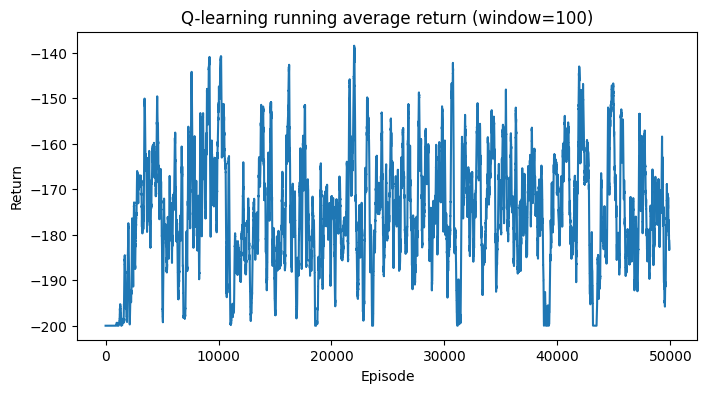

In [ ]:
# implement Q-learning and keep training history
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym


def q_learning(
    environment,
    discretize_state_function,
    number_of_position_bins,
    number_of_velocity_bins,
    number_of_episodes=50000,
    discount_factor=0.99,
    learning_rate=0.1,
    exploration_rate=1.0,
    minimum_exploration_rate=0.05,
    exploration_decay_rate=0.999,
):

    number_of_actions = environment.action_space.n
    q_table = np.zeros(
        (number_of_position_bins, number_of_velocity_bins, number_of_actions),
        dtype=np.float32,
    )

    training_history = {
        "episode_returns": [],
        "episode_steps": [],
        "exploration_rate": [],
    }

    for episode_index in range(number_of_episodes):
        observation, _ = environment.reset()
        discrete_state = discretize_state_function(observation)

        episode_finished = False
        total_episode_return = 0.0
        total_episode_steps = 0

        while not episode_finished:
            if np.random.rand() < exploration_rate:
                selected_action = np.random.randint(number_of_actions)
            else:
                selected_action = int(
                    np.argmax(q_table[discrete_state[0], discrete_state[1], :])
                )

            next_observation, reward, terminated, truncated, _ = environment.step(selected_action)
            episode_finished = terminated or truncated
            next_discrete_state = discretize_state_function(next_observation)

            best_next_action_value = np.max(
                q_table[next_discrete_state[0], next_discrete_state[1], :]
            )
            temporal_difference_target = reward + discount_factor * best_next_action_value * (
                1 - int(episode_finished)
            )
            temporal_difference_error = (
                temporal_difference_target
                - q_table[discrete_state[0], discrete_state[1], selected_action]
            )
            q_table[discrete_state[0], discrete_state[1], selected_action] += (
                learning_rate * temporal_difference_error
            )

            discrete_state = next_discrete_state
            total_episode_return += reward
            total_episode_steps += 1

        exploration_rate = max(
            minimum_exploration_rate,
            exploration_rate * exploration_decay_rate,
        )

        training_history["episode_returns"].append(total_episode_return)
        training_history["episode_steps"].append(total_episode_steps)
        training_history["exploration_rate"].append(exploration_rate)

        if (episode_index + 1) % 500 == 0:
            average_return_last_100 = np.mean(training_history["episode_returns"][-100:])
            print(
                f"Episode {episode_index + 1:5d} | "
                f"exploration={exploration_rate:.3f} | "
                f"avg return (last 100)={average_return_last_100:.2f}"
            )

    return q_table, training_history


#fresh non-rendered environment for training
environment_for_training = gym.make("MountainCar-v0")
q_table, training_history = q_learning(
    environment_for_training,
    discretize_state,
    N_POS,
    N_VEL,
    number_of_episodes=50000,
)
environment_for_training.close()

final_average_return_last_100 = np.mean(training_history["episode_returns"][-100:])
print(f"Final 100-episode average return: {final_average_return_last_100:.2f}")

#quick learning curve
moving_average_window = 100
running_average_returns = np.convolve(
    training_history["episode_returns"],
    np.ones(moving_average_window) / moving_average_window,
    mode="valid",
)

plt.figure(figsize=(8, 4))
plt.plot(running_average_returns)
plt.title("Q-learning running average return (window=100)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

returns with current hyperparams and q-learning is ass?


Training grid 12x12
Episode  500 | eps=0.779 | avg return (last 100)=-200.00
Episode 1000 | eps=0.606 | avg return (last 100)=-200.00
Episode 1500 | eps=0.472 | avg return (last 100)=-200.00
Episode 2000 | eps=0.368 | avg return (last 100)=-198.51
Episode 2500 | eps=0.286 | avg return (last 100)=-194.59
Episode 3000 | eps=0.223 | avg return (last 100)=-191.41
Episode 3500 | eps=0.174 | avg return (last 100)=-184.44
Episode 4000 | eps=0.135 | avg return (last 100)=-181.27
Episode 4500 | eps=0.105 | avg return (last 100)=-184.46
Episode 5000 | eps=0.082 | avg return (last 100)=-173.24
Episode 5500 | eps=0.064 | avg return (last 100)=-156.63
Episode 6000 | eps=0.050 | avg return (last 100)=-187.36
Episode 6500 | eps=0.039 | avg return (last 100)=-174.46
Episode 7000 | eps=0.030 | avg return (last 100)=-169.96
Episode 7500 | eps=0.023 | avg return (last 100)=-184.50
Episode 8000 | eps=0.018 | avg return (last 100)=-189.15
Episode 8500 | eps=0.014 | avg return (last 100)=-195.02
Episode 90

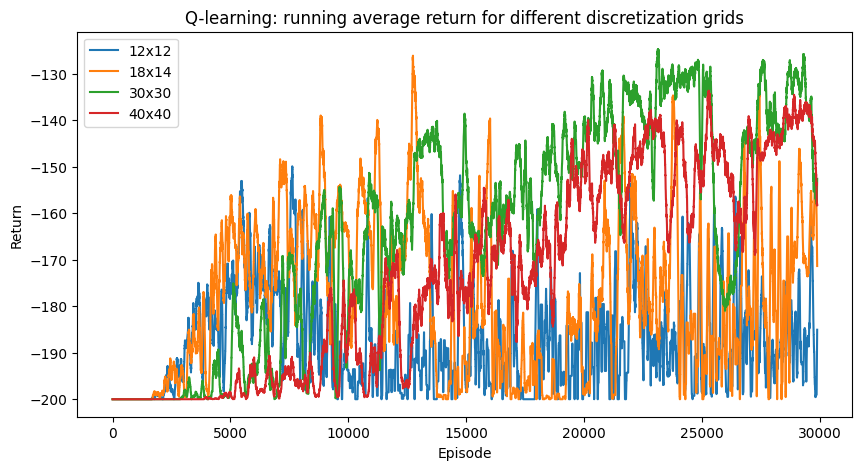


Summary (final average return over last 100 episodes):
Grid 12x12: -185.05
Grid 18x14: -171.34
Grid 30x30: -152.58
Grid 40x40: -158.21


In [25]:
# Task 2: compare a range of discretization grids
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym


position_low, position_high = -1.2, 0.6
velocity_low, velocity_high = -0.07, 0.07


def build_discretize_state_function(number_of_position_bins, number_of_velocity_bins):
    position_edges = np.linspace(position_low, position_high, number_of_position_bins + 1)
    velocity_edges = np.linspace(velocity_low, velocity_high, number_of_velocity_bins + 1)

    def discretize_state_for_grid(continuous_state):
        position_value, velocity_value = continuous_state
        position_index = np.digitize(position_value, position_edges[1:-1])
        velocity_index = np.digitize(velocity_value, velocity_edges[1:-1])
        return position_index, velocity_index

    return discretize_state_for_grid


# (position bins, velocity bins)
grid_settings = [(12, 12), (18, 14), (30, 30), (40, 40)]
number_of_episodes_per_grid = 30000
moving_average_window = 100

results_by_grid = {}

for number_of_position_bins, number_of_velocity_bins in grid_settings:
    print(f"\nTraining grid {number_of_position_bins}x{number_of_velocity_bins}")

    discretize_state_for_current_grid = build_discretize_state_function(
        number_of_position_bins,
        number_of_velocity_bins,
    )

    environment_for_grid = gym.make("MountainCar-v0")

    # Positional args keep this compatible with both q_learning signatures used earlier.
    q_table_for_grid, training_history_for_grid = q_learning(
        environment_for_grid,
        discretize_state_for_current_grid,
        number_of_position_bins,
        number_of_velocity_bins,
        number_of_episodes_per_grid,
        0.99,
        0.05,
        1.0,
        0.01,
        0.9995,
    )
    environment_for_grid.close()

    running_average_returns_for_grid = np.convolve(
        training_history_for_grid["episode_returns"] if "episode_returns" in training_history_for_grid else training_history_for_grid["returns"],
        np.ones(moving_average_window) / moving_average_window,
        mode="valid",
    )

    if "episode_returns" in training_history_for_grid:
        final_average_return_last_100 = np.mean(training_history_for_grid["episode_returns"][-100:])
    else:
        final_average_return_last_100 = np.mean(training_history_for_grid["returns"][-100:])

    print(f"Final avg return (last 100): {final_average_return_last_100:.2f}")

    results_by_grid[(number_of_position_bins, number_of_velocity_bins)] = {
        "q_table": q_table_for_grid,
        "history": training_history_for_grid,
        "running_average_returns": running_average_returns_for_grid,
        "final_average_return_last_100": final_average_return_last_100,
    }


plt.figure(figsize=(10, 5))
for (number_of_position_bins, number_of_velocity_bins), result in results_by_grid.items():
    plt.plot(
        result["running_average_returns"],
        label=f"{number_of_position_bins}x{number_of_velocity_bins}",
    )

plt.title("Q-learning: running average return for different discretization grids")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()


print("\nSummary (final average return over last 100 episodes):")
for (number_of_position_bins, number_of_velocity_bins), result in results_by_grid.items():
    print(
        f"Grid {number_of_position_bins}x{number_of_velocity_bins}: "
        f"{result['final_average_return_last_100']:.2f}"
    )

Re task 3, not really sure? dont immeadiatly see how i can better the return/episode with additional feature eng... 

# p2 ex5, planning

In [10]:
import numpy as np
from collections import defaultdict

# Each row is: state_row, state_col, action_logged, reward, next_state_row, next_state_col
transition_data = np.loadtxt("powered_flight.txt", dtype=int)

transition_count_by_state_action = defaultdict(lambda: defaultdict(int))
reward_sum_by_state_action = defaultdict(float)
visit_count_by_state_action = defaultdict(int)

#think ((s(i,j), a, r, s'(i',j') in each row of transition_data))
for current_state_row,current_state_column,logged_action,observed_reward,next_state_row,next_state_column in transition_data:
    environment_action = int(logged_action) - 1

    current_state = (int(current_state_row), int(current_state_column))
    next_state = (int(next_state_row), int(next_state_column))
    state_action_key = (current_state, environment_action)

    transition_count_by_state_action[state_action_key][next_state] += 1
    reward_sum_by_state_action[state_action_key] += float(observed_reward)
    visit_count_by_state_action[state_action_key] += 1

#our model m_hat here is sort of similar to a "counting estimator" 
model_M_hat = {}
for state_action_key in transition_count_by_state_action:
    number_of_visits = visit_count_by_state_action[state_action_key]

    transition_probability_distribution = {
        candidate_next_state: transition_count / number_of_visits
        for candidate_next_state, transition_count in transition_count_by_state_action[state_action_key].items()
    }

    expected_reward = reward_sum_by_state_action[state_action_key] / number_of_visits

    model_M_hat[state_action_key] = {
        "transition_probabilities": transition_probability_distribution,
        "expected_reward": expected_reward,
        "visit_count": number_of_visits,
    }

print("number of (state, action) entries:", len(model_M_hat))
print("example entry:", next(iter(model_M_hat.items())))

number of (state, action) entries: 909
example entry: (((18, 17), 0), {'transition_probabilities': {(17, 13): 1.0}, 'expected_reward': 0.0, 'visit_count': 1})


### T2, Dyna

In [12]:
#need a lot of helper functions ideally 

def extract_grid_state_from_observation(environment_observation):
    return tuple(int(position_value) for position_value in environment_observation["agent"]["pos"])


def epsilon_greedy_action_selection(
    q_value_table,
    current_state,
    number_of_actions,
    exploration_rate,
    random_number_generator,
):
    if random_number_generator.random() < exploration_rate:
        return int(random_number_generator.integers(number_of_actions))
    return int(np.argmax(q_value_table[current_state]))


def q_learning_style_update(
    q_value_table,
    current_state,
    action_index,
    observed_reward,
    next_state,
    is_terminal_state,
    learning_rate,
    discount_factor,
):
    best_next_state_action_value = float(np.max(q_value_table[next_state]))
    temporal_difference_target = observed_reward + (
        0.0 if is_terminal_state else discount_factor * best_next_state_action_value
    )
    temporal_difference_error = temporal_difference_target - q_value_table[current_state][action_index]
    q_value_table[current_state][action_index] += learning_rate * temporal_difference_error


def sample_transition_from_learned_model(
    learned_model_M_hat,
    sampled_state,
    sampled_action,
    random_number_generator,
):
    state_action_key = (tuple(sampled_state), int(sampled_action))
    if state_action_key not in learned_model_M_hat:
        return None

    transition_distribution = learned_model_M_hat[state_action_key]["transition_probabilities"]
    next_state_candidates = list(transition_distribution.keys())
    next_state_probabilities = np.array(list(transition_distribution.values()), dtype=float)

    sampled_next_state_index = int(
        random_number_generator.choice(len(next_state_candidates), p=next_state_probabilities)
    )
    sampled_next_state = next_state_candidates[sampled_next_state_index]
    sampled_expected_reward = float(learned_model_M_hat[state_action_key]["expected_reward"])
    sampled_terminal_flag = sampled_expected_reward > 0.0

    return sampled_next_state, sampled_expected_reward, sampled_terminal_flag


def run_dyna_q_with_learned_model(
    environment,
    learned_model_M_hat,
    number_of_episodes=1000,
    planning_steps_per_real_step=20,
    learning_rate=0.2,
    discount_factor=0.99,
    exploration_rate_start=0.3,
    exploration_rate_minimum=0.02,
    exploration_rate_decay=0.995,
    maximum_steps_per_episode=400,
    random_seed=42,
):
    """
    Dyna-Q using a fixed learned model M_hat from logged data.
    Reuses the same epsilon-greedy + TD update pattern as q_learning.
    """
    random_number_generator = np.random.default_rng(random_seed)
    number_of_actions = environment.action_space.n

    # Q-table as sparse dict: state -> np.array(action_values)
    q_value_table = defaultdict(lambda: np.zeros(number_of_actions, dtype=np.float32))

    # Keep only model entries with valid action range for this environment.
    valid_model_state_actions = [
        (state_action_key[0], state_action_key[1])
        for state_action_key in learned_model_M_hat.keys()
        if 0 <= state_action_key[1] < number_of_actions
    ]

    training_history = {
        "episode_returns": [],
        "episode_success": [],
        "exploration_rate": [],
    }

    exploration_rate = exploration_rate_start

    for episode_index in range(number_of_episodes):
        environment_observation, _ = environment.reset()
        current_state = extract_grid_state_from_observation(environment_observation)

        total_episode_return = 0.0
        reached_goal = False

        for _ in range(maximum_steps_per_episode):
            selected_action = epsilon_greedy_action_selection(
                q_value_table,
                current_state,
                number_of_actions,
                exploration_rate,
                random_number_generator,
            )

            next_observation, observed_reward, terminated, truncated, _ = environment.step(selected_action)
            next_state = extract_grid_state_from_observation(next_observation)
            is_terminal_state = bool(terminated or truncated)

            # Real experience update (same core update as q_learning).
            q_learning_style_update(
                q_value_table,
                current_state,
                selected_action,
                observed_reward,
                next_state,
                is_terminal_state,
                learning_rate,
                discount_factor,
            )

            # Planning updates from learned model M_hat.
            for _ in range(planning_steps_per_real_step):
                if not valid_model_state_actions:
                    break

                sampled_state_action_index = int(
                    random_number_generator.integers(len(valid_model_state_actions))
                )
                sampled_state, sampled_action = valid_model_state_actions[sampled_state_action_index]

                sampled_transition = sample_transition_from_learned_model(
                    learned_model_M_hat,
                    sampled_state,
                    sampled_action,
                    random_number_generator,
                )
                if sampled_transition is None:
                    continue

                (
                    sampled_next_state,
                    sampled_expected_reward,
                    sampled_terminal_flag,
                ) = sampled_transition

                q_learning_style_update(
                    q_value_table,
                    sampled_state,
                    sampled_action,
                    sampled_expected_reward,
                    sampled_next_state,
                    sampled_terminal_flag,
                    learning_rate,
                    discount_factor,
                )

            current_state = next_state
            total_episode_return += float(observed_reward)

            if terminated:
                reached_goal = True
                break
            if truncated:
                break

        exploration_rate = max(
            exploration_rate_minimum,
            exploration_rate * exploration_rate_decay,
        )

        training_history["episode_returns"].append(total_episode_return)
        training_history["episode_success"].append(1 if reached_goal else 0)
        training_history["exploration_rate"].append(exploration_rate)

        if (episode_index + 1) % 200 == 0:
            average_return_last_100 = float(np.mean(training_history["episode_returns"][-100:]))
            success_rate_last_100 = float(np.mean(training_history["episode_success"][-100:]))
            print(
                f"Episode {episode_index + 1:4d} | "
                f"avg return(last 100)={average_return_last_100:.3f} | "
                f"success(last 100)={success_rate_last_100:.2f}"
            )

    return q_value_table, training_history


# Example run
environment_for_dyna_q = gym.make("skyscraper/GridWorld-v0")
dyna_q_values, dyna_training_history = run_dyna_q_with_learned_model(
    environment=environment_for_dyna_q,
    learned_model_M_hat=model_M_hat,
    number_of_episodes=2000,
    planning_steps_per_real_step=20,
)
environment_for_dyna_q.close()

print(
    "Final success rate over last 100 episodes:",
    float(np.mean(dyna_training_history["episode_success"][-100:])),
)

Episode  200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  400 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  600 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  800 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 1000 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 1200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 1400 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 1600 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 1800 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode 2000 | avg return(last 100)=0.000 | success(last 100)=0.00
Final success rate over last 100 episodes: 0.0


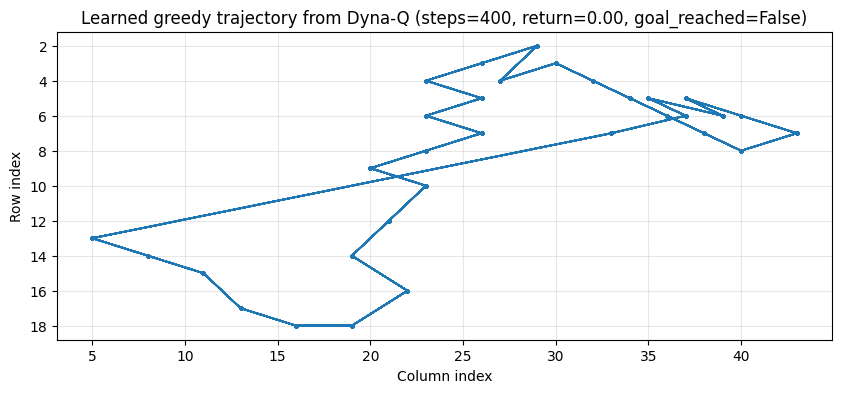

Trajectory length: 400
Trajectory return: 0.0
Reached goal: False


In [14]:
#plotting optimal trajectory learned by Dyna-Q

def rollout_greedy_policy_trajectory(q_value_table, max_steps=400):
    environment_for_rollout = gym.make("skyscraper/GridWorld-v0")
    observation, _ = environment_for_rollout.reset()
    current_state = extract_grid_state_from_observation(observation)

    visited_states = [current_state]
    cumulative_reward = 0.0
    reached_goal = False

    for _ in range(max_steps):
        greedy_action = int(np.argmax(q_value_table[current_state]))
        next_observation, reward, terminated, truncated, _ = environment_for_rollout.step(greedy_action)

        current_state = extract_grid_state_from_observation(next_observation)
        visited_states.append(current_state)
        cumulative_reward += float(reward)

        if terminated:
            reached_goal = True
            break
        if truncated:
            break

    environment_for_rollout.close()
    return visited_states, cumulative_reward, reached_goal


trajectory_states, trajectory_return, trajectory_reached_goal = rollout_greedy_policy_trajectory(
    dyna_q_values,
    max_steps=400,
)
trajectory_rows = [state_tuple[0] for state_tuple in trajectory_states]
trajectory_columns = [state_tuple[1] for state_tuple in trajectory_states]

plt.figure(figsize=(10, 4))
plt.plot(trajectory_columns, trajectory_rows, marker="o", markersize=2, linewidth=1.2)
plt.gca().invert_yaxis()
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.title(
    "Learned greedy trajectory from Dyna-Q "
    f"(steps={len(trajectory_states)-1}, return={trajectory_return:.2f}, "
    f"goal_reached={trajectory_reached_goal})"
)
plt.grid(alpha=0.3)
plt.show()

print("Trajectory length:", len(trajectory_states) - 1)
print("Trajectory return:", trajectory_return)
print("Reached goal:", trajectory_reached_goal)

agent doesnt reach the goal 

### T4, Dyna with new num sims run by the agent using M_hat + result comparison


Running Dyna-Q with planning_steps = 0


c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Episode  200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  400 | avg return(last 100)=0.000 | success(last 100)=0.00

Running Dyna-Q with planning_steps = 5
Episode  200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  400 | avg return(last 100)=0.000 | success(last 100)=0.00

Running Dyna-Q with planning_steps = 20
Episode  200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  400 | avg return(last 100)=0.000 | success(last 100)=0.00

Running Dyna-Q with planning_steps = 50
Episode  200 | avg return(last 100)=0.000 | success(last 100)=0.00
Episode  400 | avg return(last 100)=0.000 | success(last 100)=0.00


All runs complete.


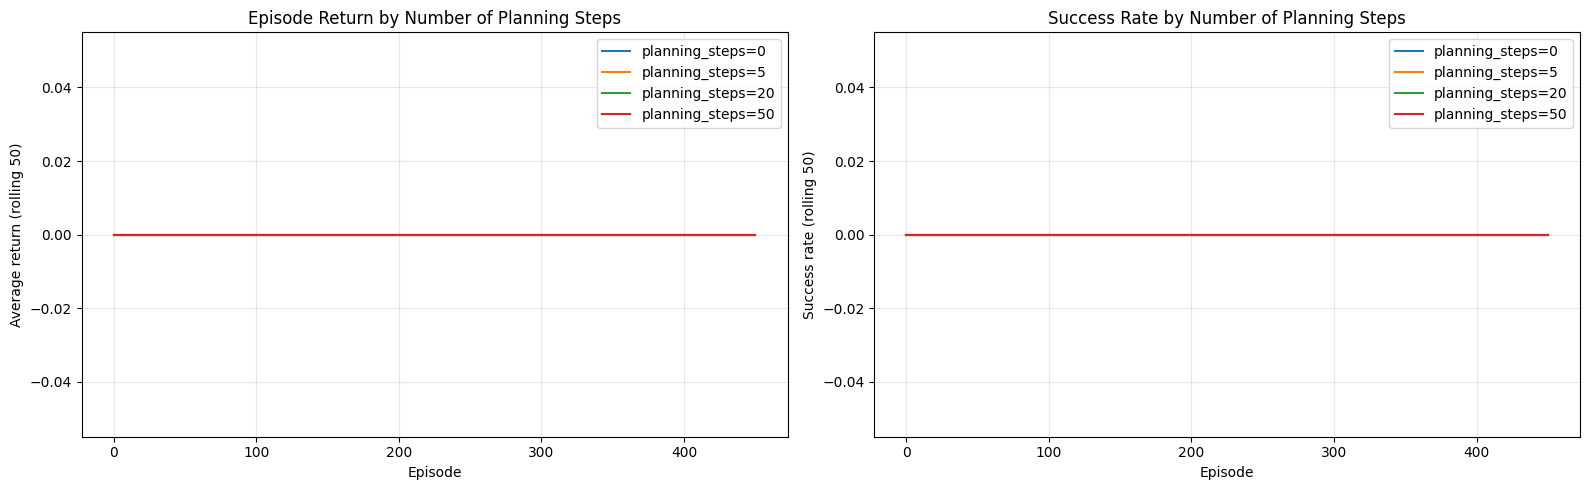


 Planning Steps |  Mean Return |   Success Rate (last 100)
------------------------------------------------------------
              0 |       0.0000 |                    0.0000
              5 |       0.0000 |                    0.0000
             20 |       0.0000 |                    0.0000
             50 |       0.0000 |                    0.0000


In [17]:
# ── Task 4: Compare Dyna-Q with different numbers of planning steps ──

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

planning_steps_to_compare = [0, 5, 20, 50]
number_of_episodes_per_run = 500
comparison_results = {}

for planning_steps in planning_steps_to_compare:
    print(f"\n{'='*60}")
    print(f"Running Dyna-Q with planning_steps = {planning_steps}")
    print(f"{'='*60}")

    environment_for_comparison = gym.make("skyscraper/GridWorld-v0")

    q_values_current, training_history_current = run_dyna_q_with_learned_model(
        environment=environment_for_comparison,
        learned_model_M_hat=model_M_hat,
        number_of_episodes=number_of_episodes_per_run,
        planning_steps_per_real_step=planning_steps,
        maximum_steps_per_episode=400,
    )

    environment_for_comparison.close()

    comparison_results[planning_steps] = {
        "q_values": q_values_current,
        "episode_returns": training_history_current["episode_returns"],
        "episode_success": training_history_current["episode_success"],
    }

print("\n\nAll runs complete.")

# ── Plot 1: Smoothed episode returns ──
smoothing_window = 50

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for planning_steps in planning_steps_to_compare:
    raw_returns = comparison_results[planning_steps]["episode_returns"]
    smoothed_returns = np.convolve(
        raw_returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    axes[0].plot(smoothed_returns, label=f"planning_steps={planning_steps}")

axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Average return (rolling {smoothing_window})")
axes[0].set_title("Episode Return by Number of Planning Steps")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: Smoothed success rate ──
for planning_steps in planning_steps_to_compare:
    raw_success = comparison_results[planning_steps]["episode_success"]
    smoothed_success = np.convolve(
        raw_success, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    axes[1].plot(smoothed_success, label=f"planning_steps={planning_steps}")

axes[1].set_xlabel("Episode")
axes[1].set_ylabel(f"Success rate (rolling {smoothing_window})")
axes[1].set_title("Success Rate by Number of Planning Steps")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'Planning Steps':>15} | {'Mean Return':>12} | {'Success Rate (last 100)':>25}")
print("-" * 60)
for planning_steps in planning_steps_to_compare:
    mean_return = float(np.mean(comparison_results[planning_steps]["episode_returns"]))
    success_rate_last_100 = float(np.mean(comparison_results[planning_steps]["episode_success"][-100:]))
    print(f"{planning_steps:>15} | {mean_return:>12.4f} | {success_rate_last_100:>25.4f}")

atp the main issue is sparse rewards, with only really the target "state" having a reward >0. best guess for why the model still doesnt reach it is that it simply havent stumbled upon the reward through exploration? can look at: When the model is wrong, 8.3 in Sutton and Barto for similar prob. 